In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/Fall2025_HCCC/Final-Project

/content/drive/MyDrive/Fall2025_HCCC/Final-Project


In [ ]:
pwd

'/content/drive/MyDrive/Fall2025_HCCC/Final-Project'

In [ ]:
ls

 Coastline.ipynb
 DefaultDataset1.csv
 DefaultDataset2.csv
 DefaultDataset3.csv
 ERA5-hourly-data-on-pressure-levels-from-1940-to-present/
'ERA5 hourly data on single levels from 1940 to present'/
 Final-Project1.ipynb
 Final-Project2.ipynb
 Final-Project3.ipynb
 generated-final-images/
 generated-images-2/
 ibtracs.ALL.list.v04r01.csv
 ibtracs_storms_summary.csv
'Mean Genesis Latitude Trend (1980–2024).png'
'Mean Genesis Latitude Trend – Northern Hemisphere.png'
'Mean Genesis Latitude Trend – Southern Hemisphere.png'
'Mean Max Intensity Latitude Trend (1980–2024).png'
'Mean Proximity to Midlatitude Coastline Proxy (1980–2024).png'
 ne_50m_coastline/
'Proportion of Trees Experiencing CD (15-50 yrs) along the Latitudinal Gradient.png'
'Proportion of Trees Experiencing CD (<15 yrs) along the Latitudinal Gradient.png'
'Proportion of Trees Experiencing CD (>50 yrs) along the Latitudinal Gradient.png'
'Storm Genesis vs Max Intensity Latitude Trends (1980–2024).png'
 wp_genesis_1980_2024.csv

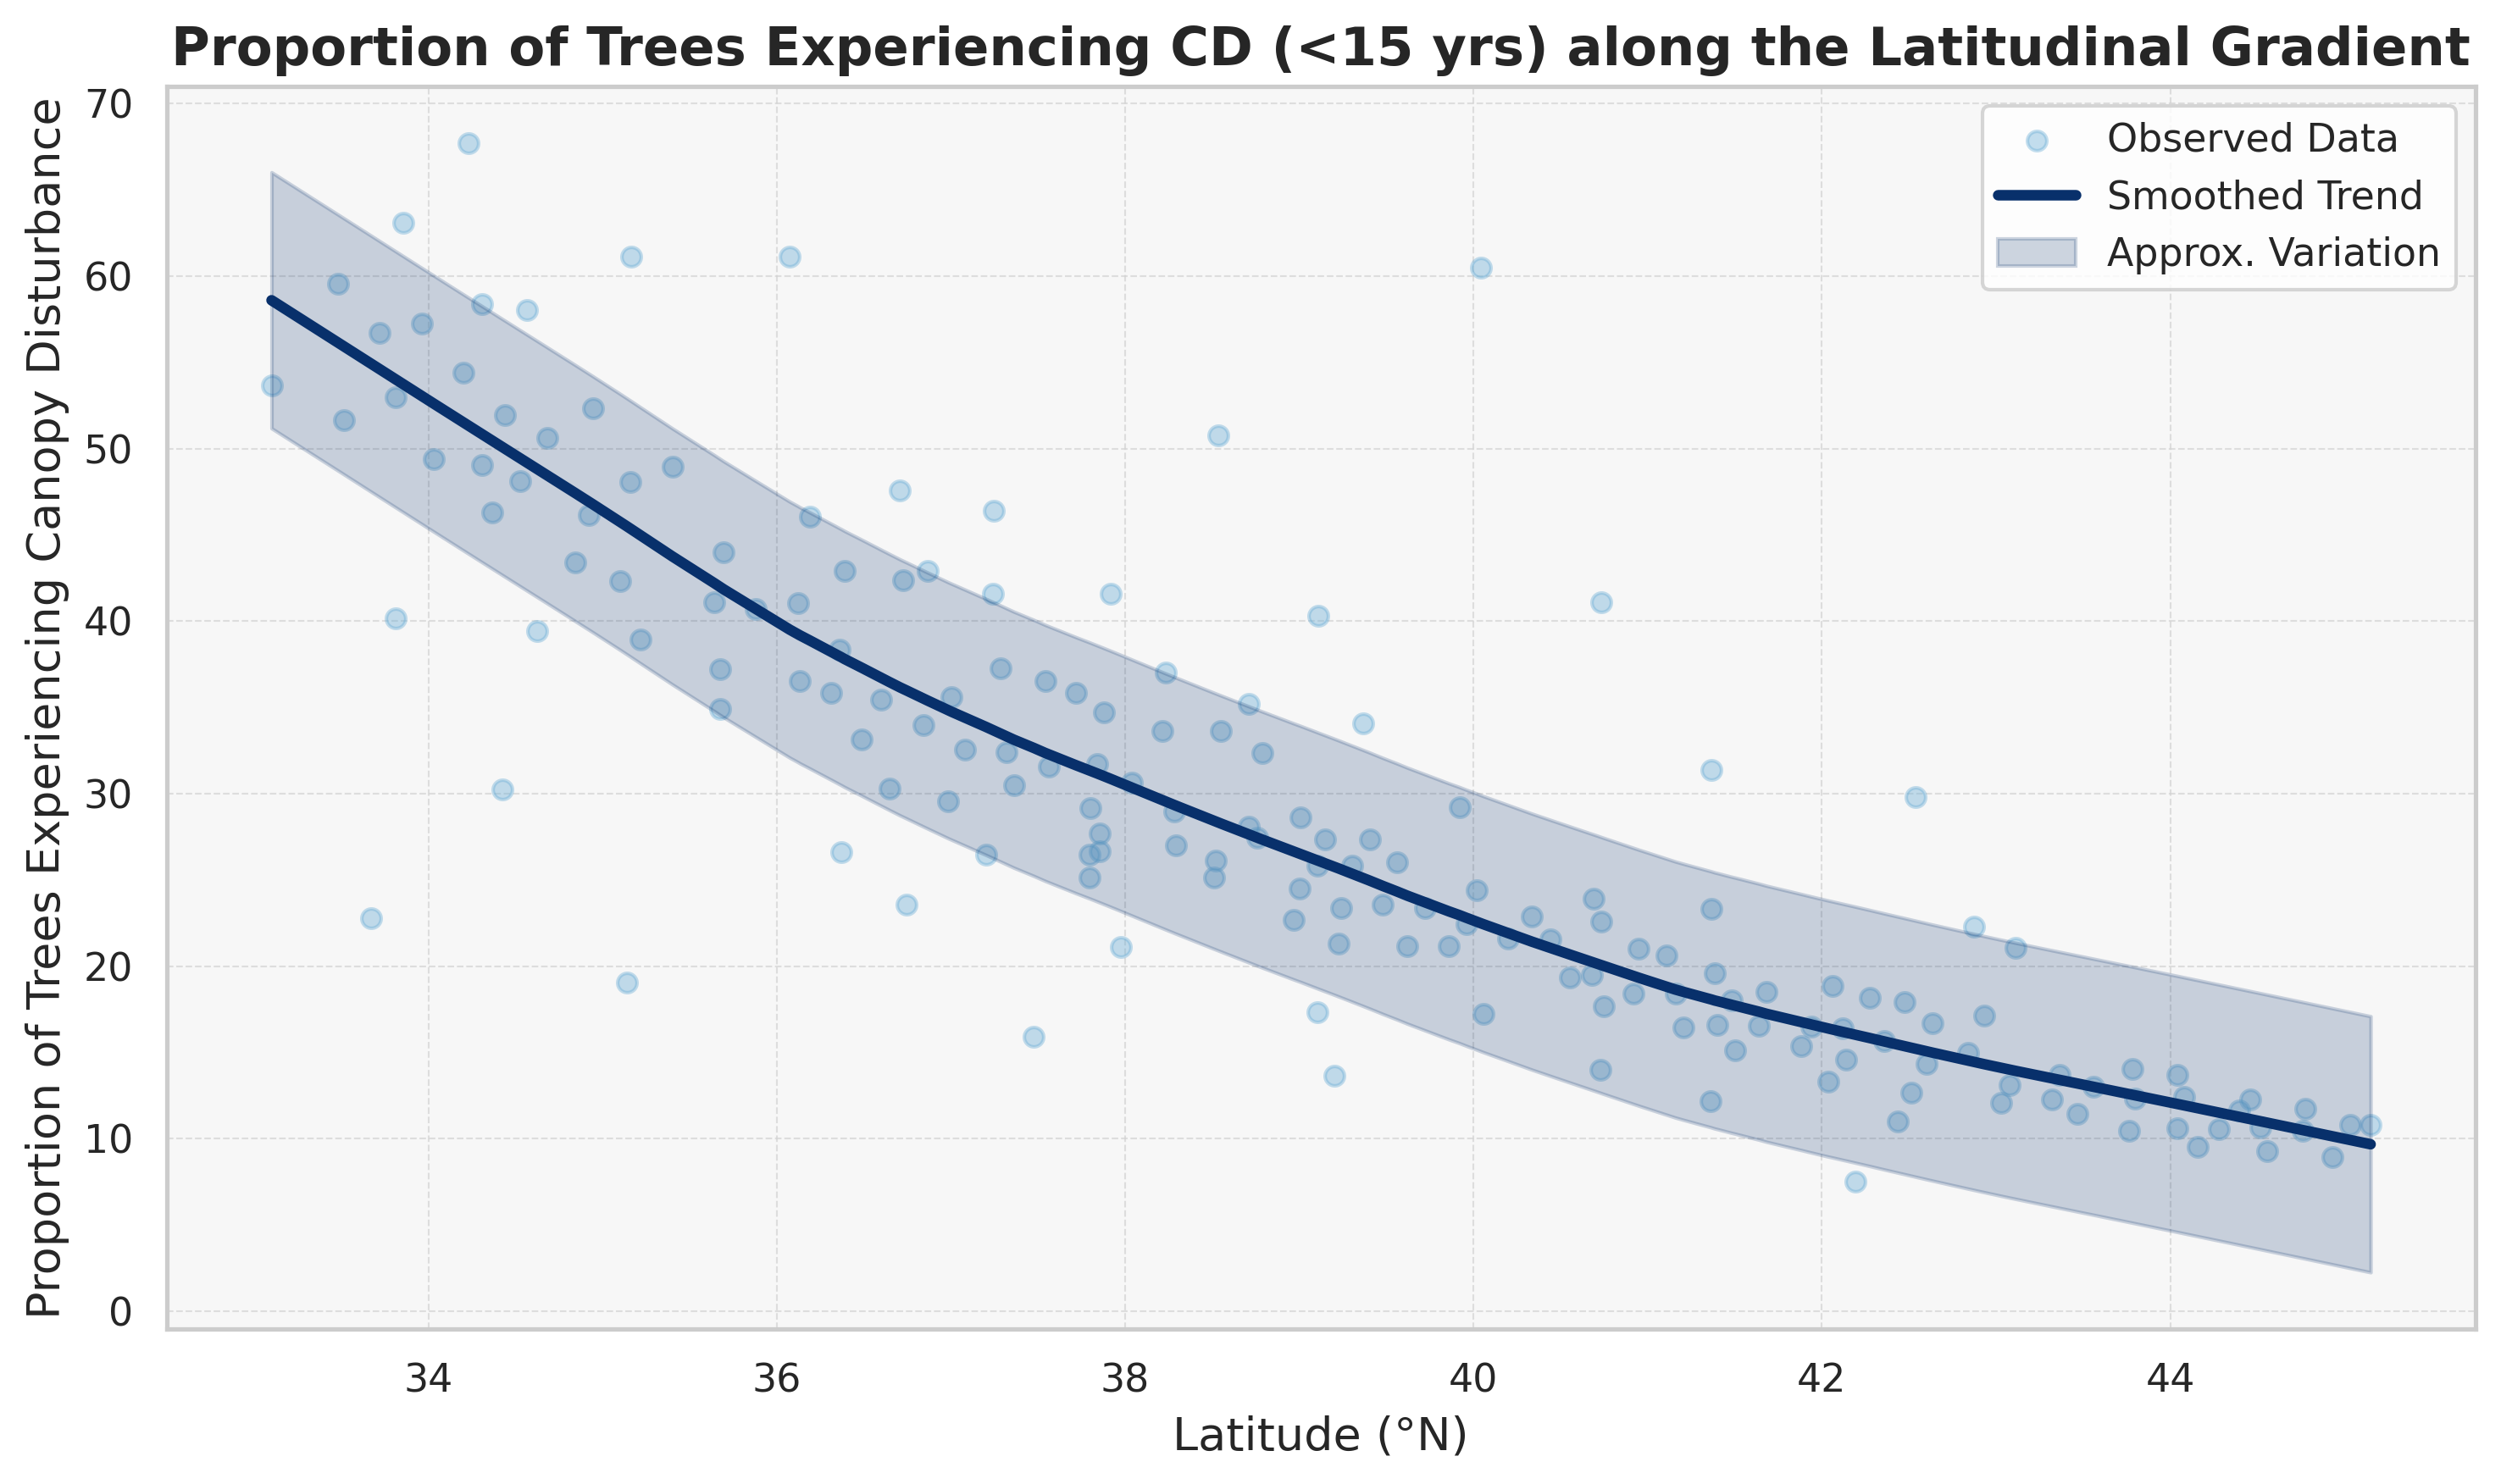

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np

# ---- Load Dataset ----
df = pd.read_csv("DefaultDataset1.csv", header=None)
df.columns = ["Latitude (degrees North)", "Proportion of Trees Experiencing CD"]
df = df.sort_values("Latitude (degrees North)")

# ---- Compute LOWESS smoothing ----
frac = 0.35  # smoothing parameter
lowess_smoothed = lowess(
    endog=df["Proportion of Trees Experiencing CD"],
    exog=df["Latitude (degrees North)"],
    frac=frac
)

# ---- Optional: compute residuals for shading ----
residuals = df["Proportion of Trees Experiencing CD"].values - \
            np.interp(df["Latitude (degrees North)"], lowess_smoothed[:,0], lowess_smoothed[:,1])
std_resid = np.std(residuals)

# ---- Custom Style ----
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6), dpi=300)
ax = plt.gca()
ax.set_facecolor("#f7f7f7")
plt.grid(color="lightgrey", linestyle="--", linewidth=0.5, alpha=0.7)

# ---- Raw Data Points (Optional, small and light) ----
plt.scatter(
    df["Latitude (degrees North)"],
    df["Proportion of Trees Experiencing CD"],
    color="#6baed6",
    alpha=0.4,
    s=30,
    label="Observed Data"
)

# ---- Smoothed Line ----
plt.plot(
    lowess_smoothed[:,0],
    lowess_smoothed[:,1],
    color="#08306b",
    linewidth=3,
    label="Smoothed Trend"
)

# ---- Shaded area around trend (±1 SD of residuals) ----
plt.fill_between(
    lowess_smoothed[:,0],
    lowess_smoothed[:,1] - std_resid,
    lowess_smoothed[:,1] + std_resid,
    color="#08306b",
    alpha=0.2,
    label="Approx. Variation"
)

# ---- Labels & Title ----
plt.xlabel("Latitude (°N)", fontsize=13)
plt.ylabel("Proportion of Trees Experiencing Canopy Disturbance", fontsize=13)
plt.title(
    "Proportion of Trees Experiencing CD (<15 yrs) along the Latitudinal Gradient",
    fontsize=15,
    weight="bold"
)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("Proportion of Trees Experiencing CD (<15 yrs) along the Latitudinal Gradient.png")
plt.show()


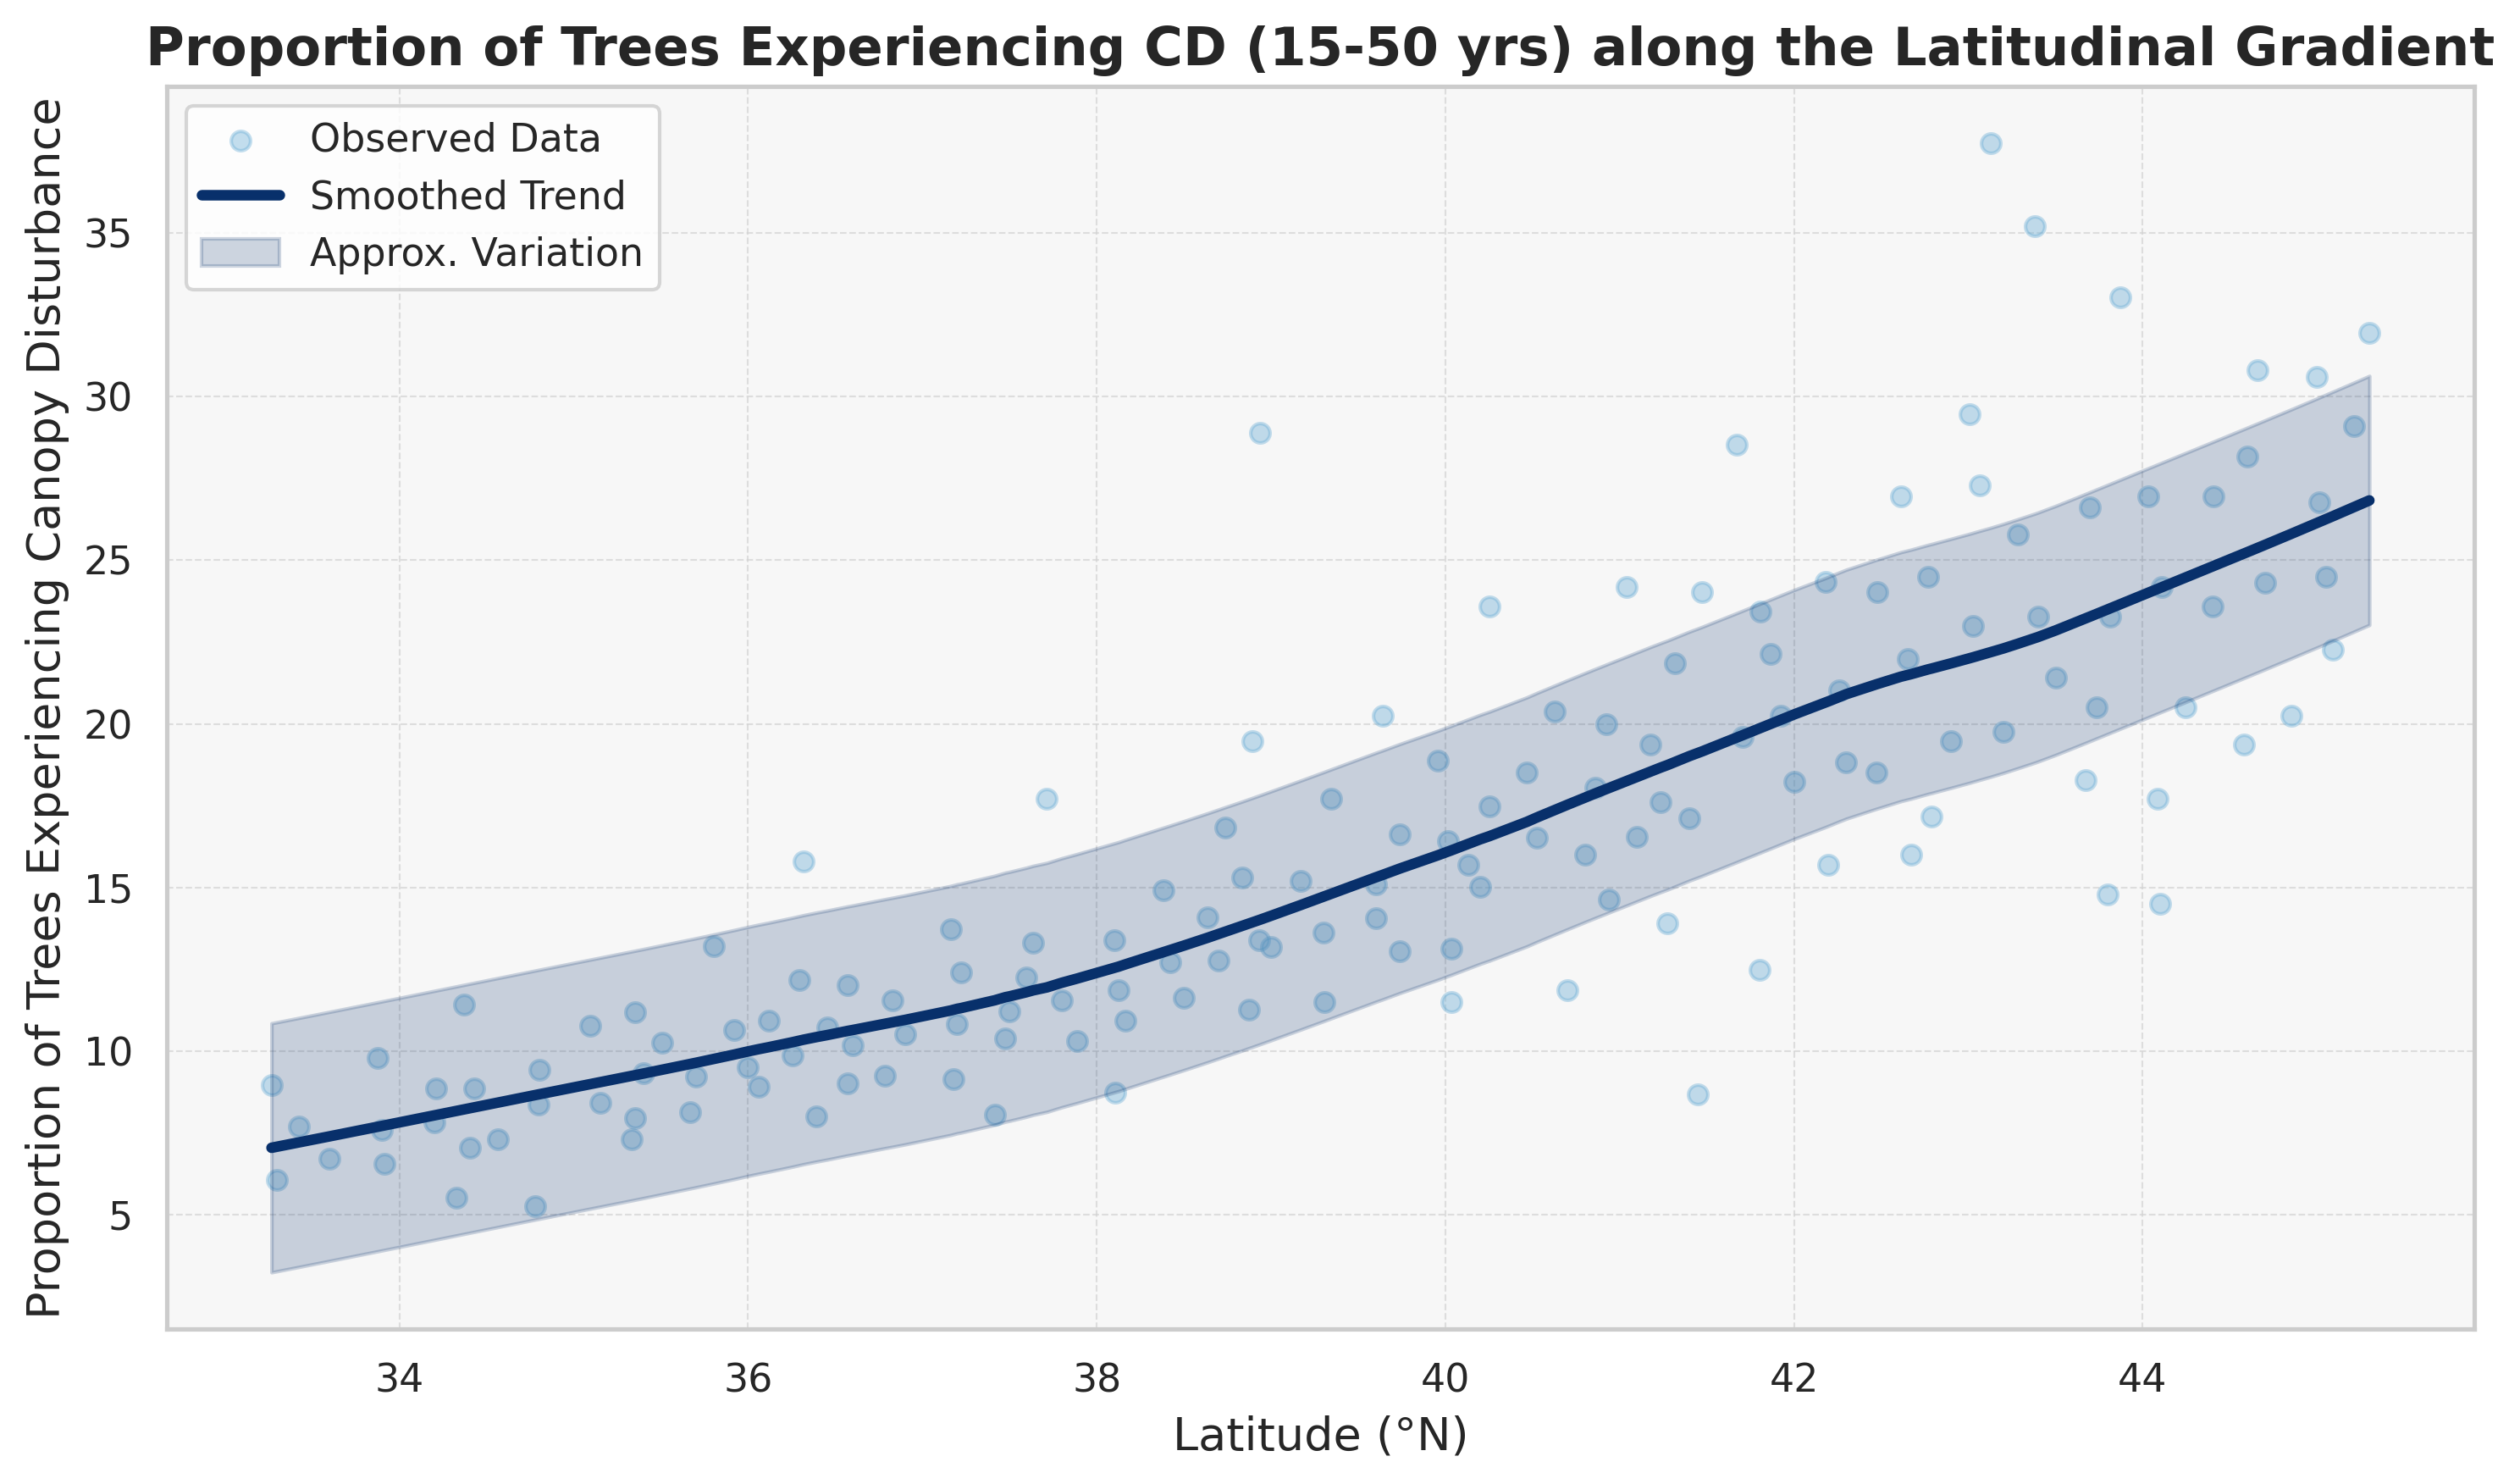

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np

# ---- Load Dataset ----
df = pd.read_csv("DefaultDataset2.csv", header=None)
df.columns = ["Latitude (degrees North)", "Proportion of Trees Experiencing CD"]
df = df.sort_values("Latitude (degrees North)")

# ---- Compute LOWESS smoothing ----
frac = 0.35  # smoothing parameter
lowess_smoothed = lowess(
    endog=df["Proportion of Trees Experiencing CD"],
    exog=df["Latitude (degrees North)"],
    frac=frac
)

# ---- Optional: compute residuals for shading ----
residuals = df["Proportion of Trees Experiencing CD"].values - \
            np.interp(df["Latitude (degrees North)"], lowess_smoothed[:,0], lowess_smoothed[:,1])
std_resid = np.std(residuals)

# ---- Custom Style ----
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6), dpi=300)
ax = plt.gca()
ax.set_facecolor("#f7f7f7")
plt.grid(color="lightgrey", linestyle="--", linewidth=0.5, alpha=0.7)

# ---- Raw Data Points (Optional, small and light) ----
plt.scatter(
    df["Latitude (degrees North)"],
    df["Proportion of Trees Experiencing CD"],
    color="#6baed6",
    alpha=0.4,
    s=30,
    label="Observed Data"
)

# ---- Smoothed Line ----
plt.plot(
    lowess_smoothed[:,0],
    lowess_smoothed[:,1],
    color="#08306b",
    linewidth=3,
    label="Smoothed Trend"
)

# ---- Shaded area around trend (±1 SD of residuals) ----
plt.fill_between(
    lowess_smoothed[:,0],
    lowess_smoothed[:,1] - std_resid,
    lowess_smoothed[:,1] + std_resid,
    color="#08306b",
    alpha=0.2,
    label="Approx. Variation"
)

# ---- Labels & Title ----
plt.xlabel("Latitude (°N)", fontsize=13)
plt.ylabel("Proportion of Trees Experiencing Canopy Disturbance", fontsize=13)
plt.title(
    "Proportion of Trees Experiencing CD (15-50 yrs) along the Latitudinal Gradient",
    fontsize=15,
    weight="bold"
)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("Proportion of Trees Experiencing CD (15-50 yrs) along the Latitudinal Gradient.png")
plt.show()


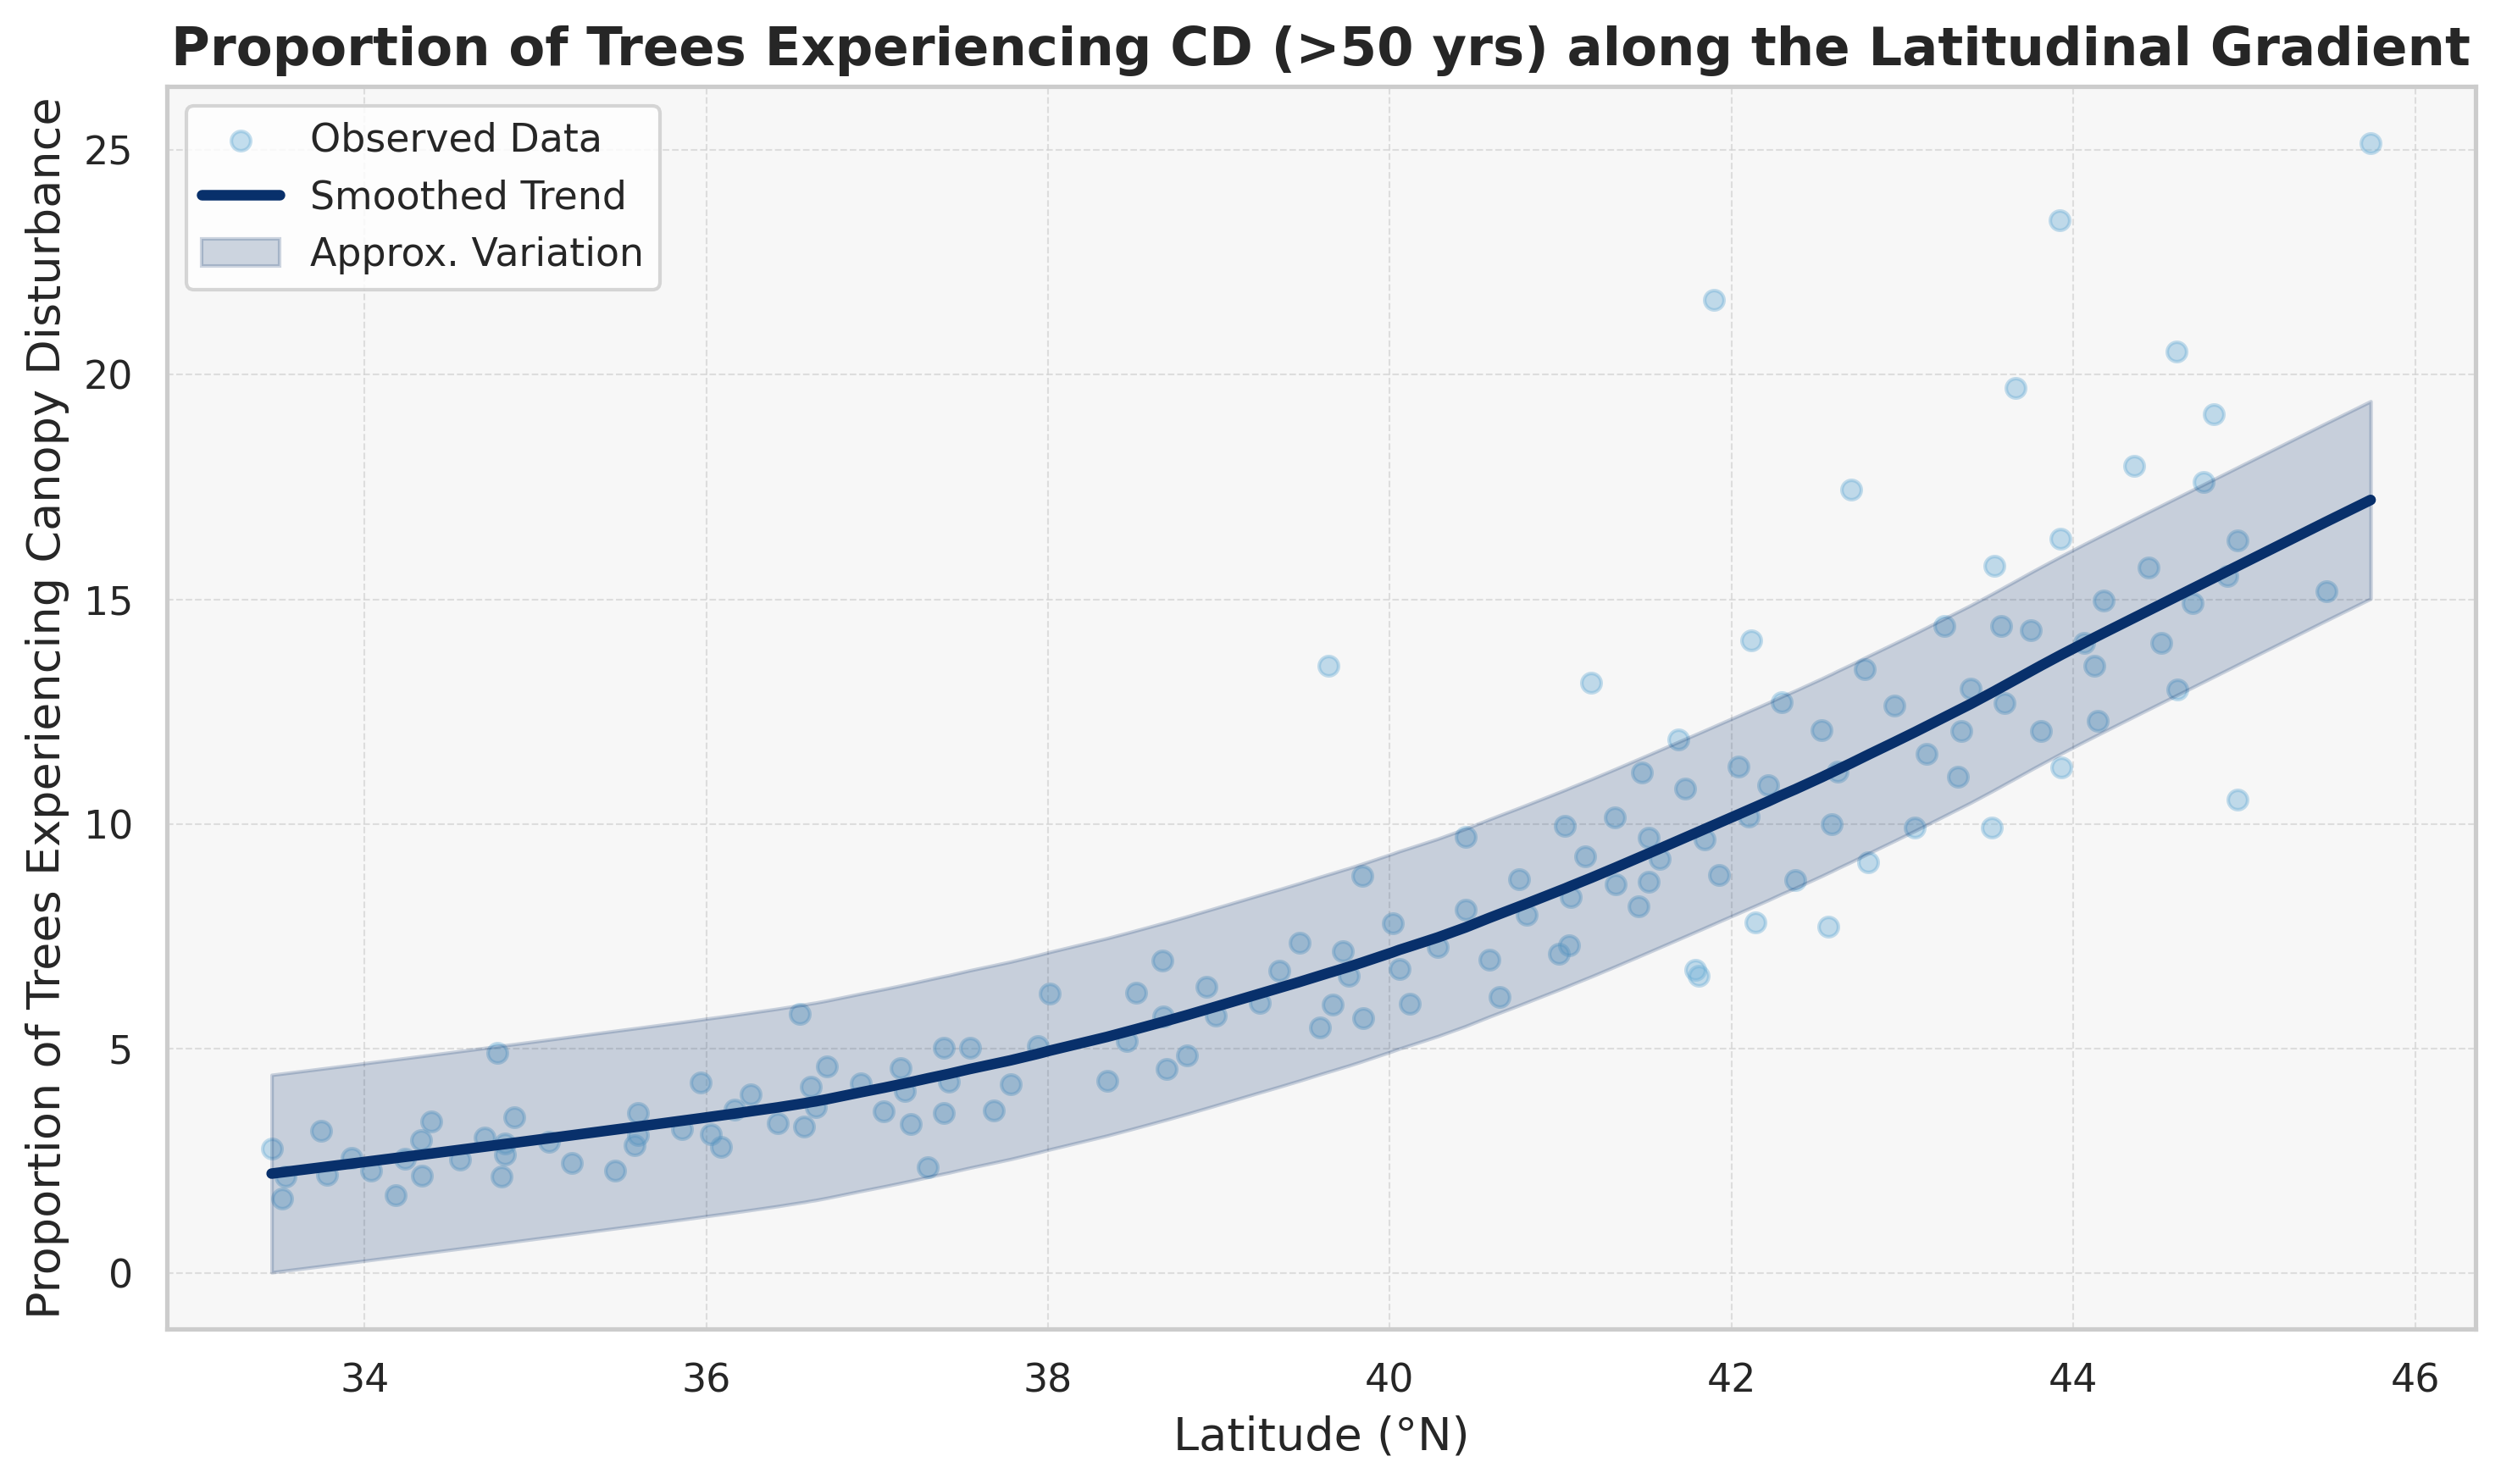

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np

# ---- Load Dataset ----
df = pd.read_csv("DefaultDataset3.csv", header=None)
df.columns = ["Latitude (degrees North)", "Proportion of Trees Experiencing CD"]
df = df.sort_values("Latitude (degrees North)")

# ---- Compute LOWESS smoothing ----
frac = 0.35  # smoothing parameter
lowess_smoothed = lowess(
    endog=df["Proportion of Trees Experiencing CD"],
    exog=df["Latitude (degrees North)"],
    frac=frac
)

# ---- Optional: compute residuals for shading ----
residuals = df["Proportion of Trees Experiencing CD"].values - \
            np.interp(df["Latitude (degrees North)"], lowess_smoothed[:,0], lowess_smoothed[:,1])
std_resid = np.std(residuals)

# ---- Custom Style ----
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6), dpi=300)
ax = plt.gca()
ax.set_facecolor("#f7f7f7")
plt.grid(color="lightgrey", linestyle="--", linewidth=0.5, alpha=0.7)

# ---- Raw Data Points (Optional, small and light) ----
plt.scatter(
    df["Latitude (degrees North)"],
    df["Proportion of Trees Experiencing CD"],
    color="#6baed6",
    alpha=0.4,
    s=30,
    label="Observed Data"
)

# ---- Smoothed Line ----
plt.plot(
    lowess_smoothed[:,0],
    lowess_smoothed[:,1],
    color="#08306b",
    linewidth=3,
    label="Smoothed Trend"
)

# ---- Shaded area around trend (±1 SD of residuals) ----
plt.fill_between(
    lowess_smoothed[:,0],
    lowess_smoothed[:,1] - std_resid,
    lowess_smoothed[:,1] + std_resid,
    color="#08306b",
    alpha=0.2,
    label="Approx. Variation"
)

# ---- Labels & Title ----
plt.xlabel("Latitude (°N)", fontsize=13)
plt.ylabel("Proportion of Trees Experiencing Canopy Disturbance", fontsize=13)
plt.title(
    "Proportion of Trees Experiencing CD (>50 yrs) along the Latitudinal Gradient",
    fontsize=15,
    weight="bold"
)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("Proportion of Trees Experiencing CD (>50 yrs) along the Latitudinal Gradient.png")
plt.show()


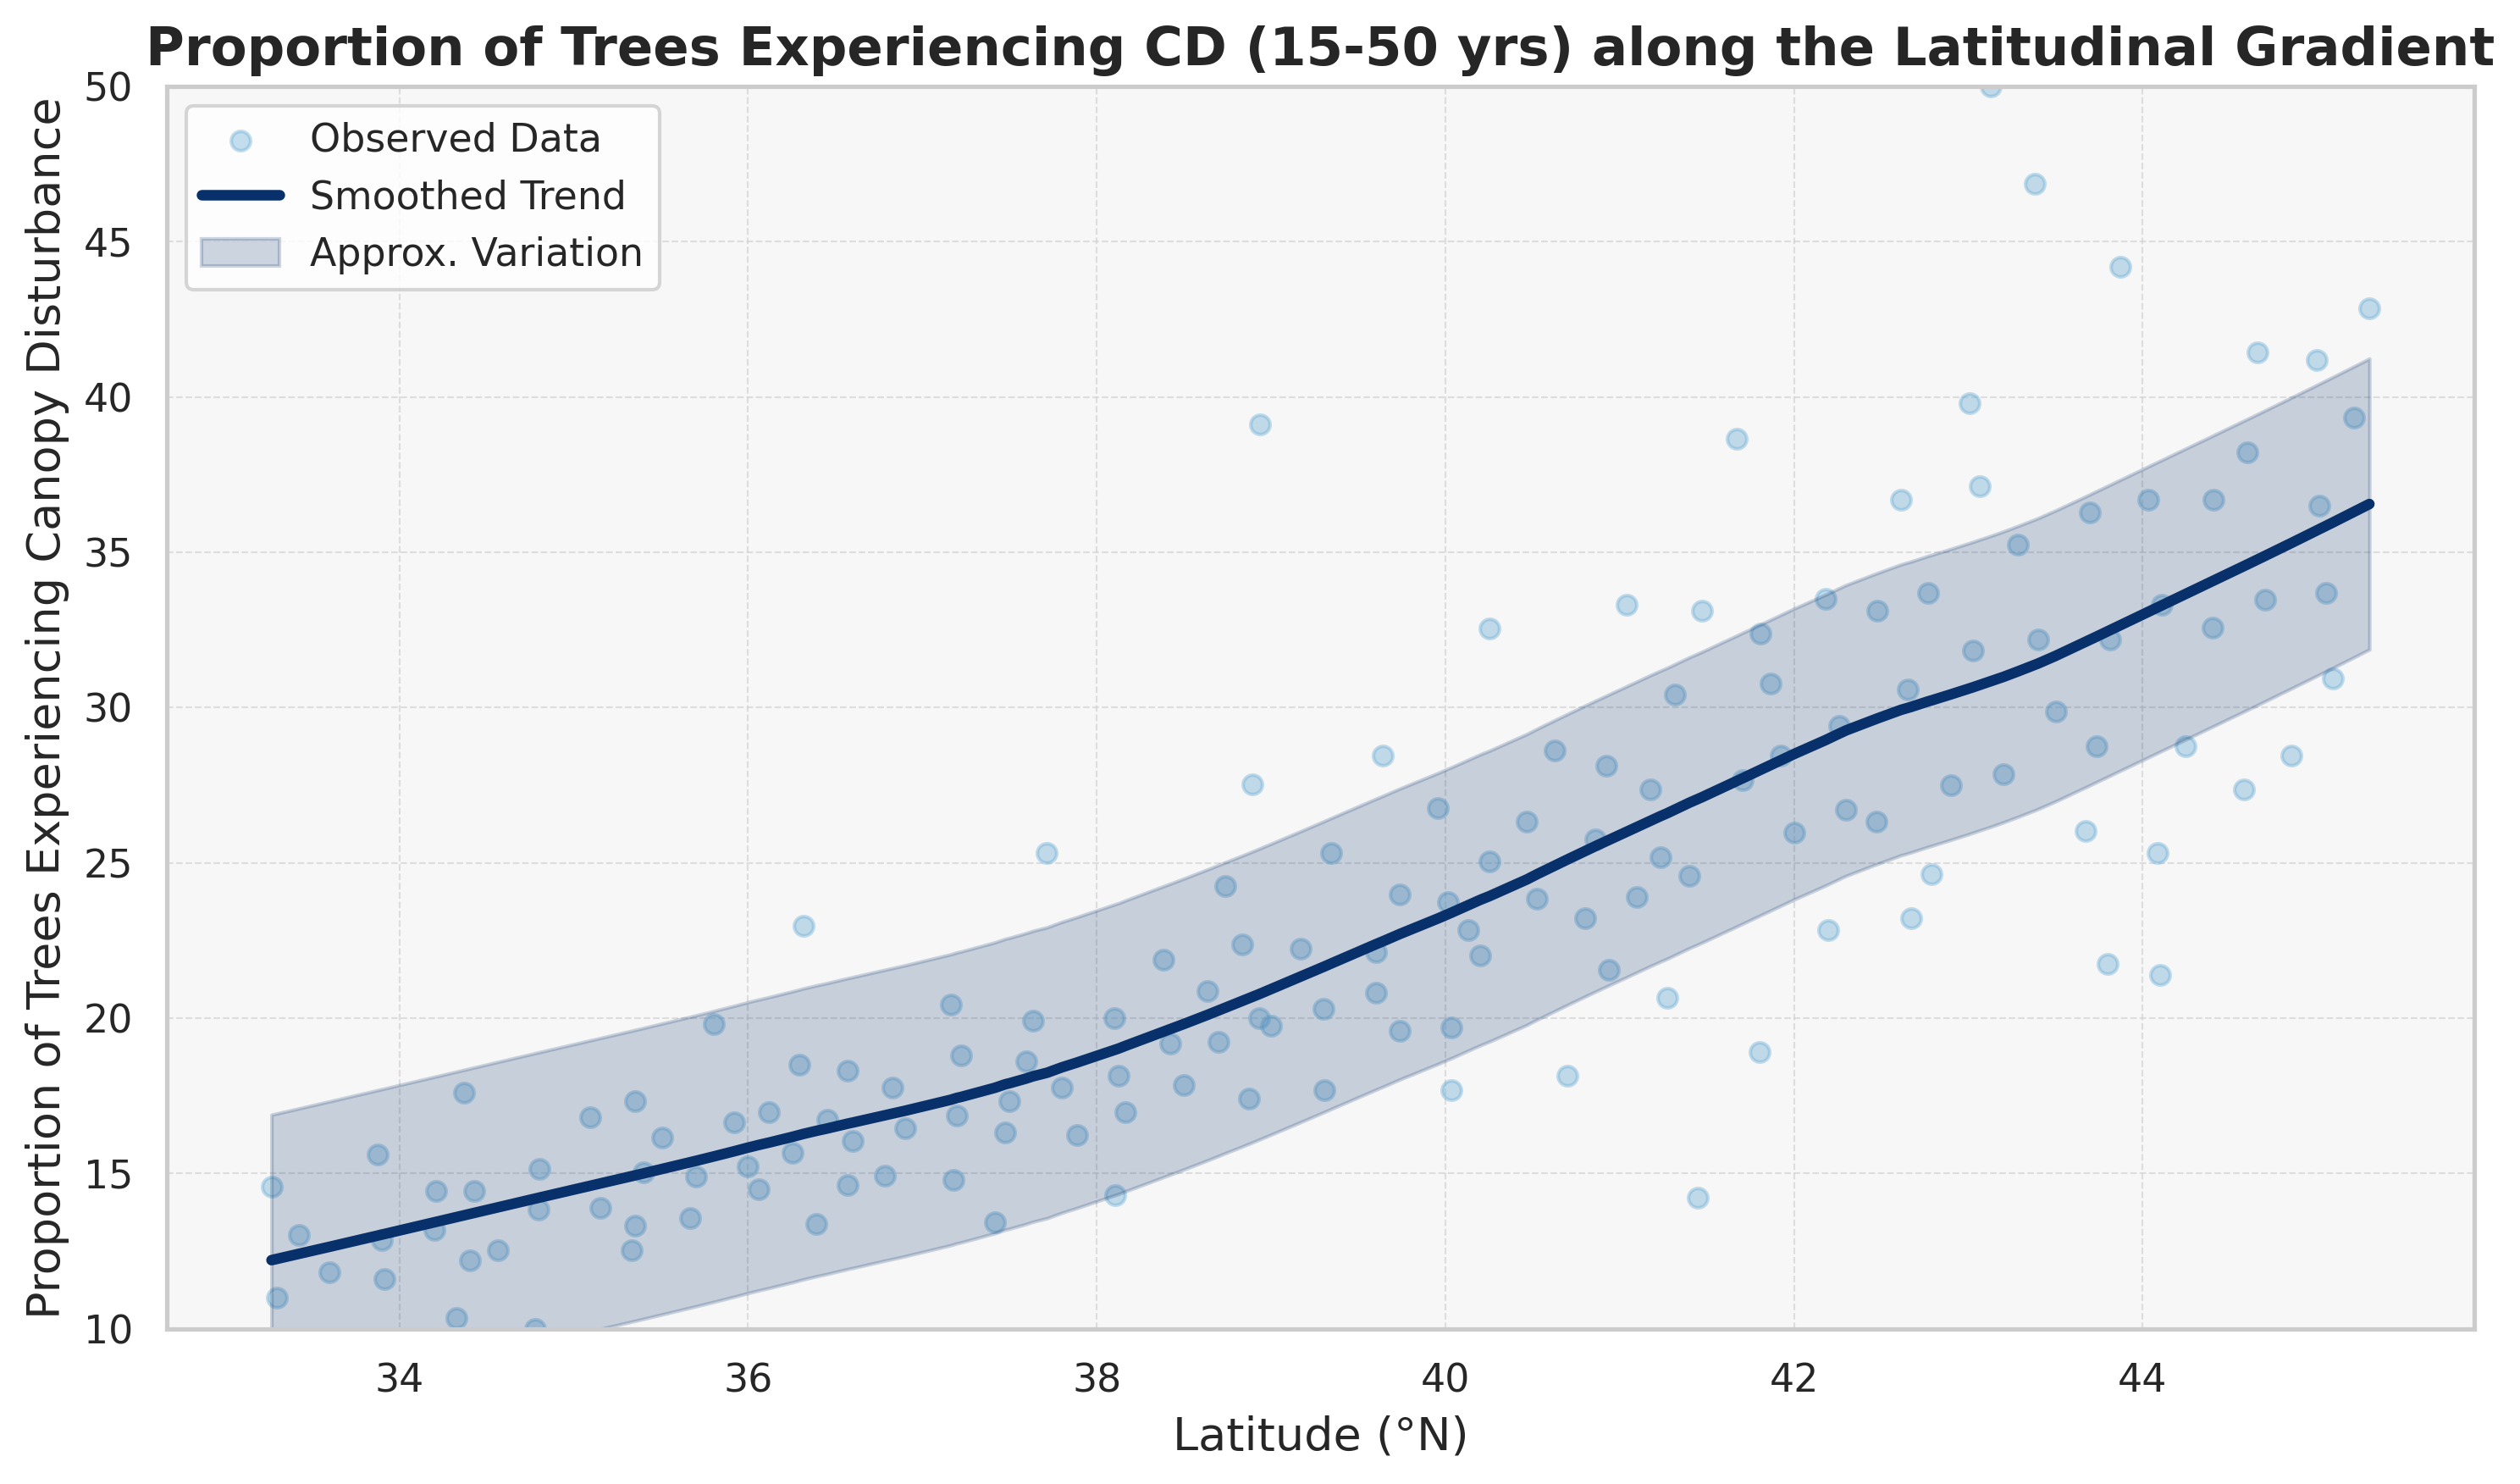

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np

# ---- Load Dataset ----
df = pd.read_csv("DefaultDataset2.csv", header=None)
df.columns = ["Latitude (degrees North)", "Proportion of Trees Experiencing CD"]
df = df.sort_values("Latitude (degrees North)")

# ---- Rescale Y-axis to 10–50 ----
y_new_min, y_new_max = 10, 50
y_old_min, y_old_max = df["Proportion of Trees Experiencing CD"].min(), df["Proportion of Trees Experiencing CD"].max()
df["CD_scaled"] = (df["Proportion of Trees Experiencing CD"] - y_old_min) / (y_old_max - y_old_min)
df["CD_scaled"] = df["CD_scaled"] * (y_new_max - y_new_min) + y_new_min

# ---- Compute LOWESS smoothing on scaled data ----
frac = 0.35  # smoothing parameter
lowess_smoothed_scaled = lowess(
    endog=df["CD_scaled"],
    exog=df["Latitude (degrees North)"],
    frac=frac
)

# ---- Compute residuals for shaded variation ----
residuals_scaled = df["CD_scaled"].values - np.interp(
    df["Latitude (degrees North)"],
    lowess_smoothed_scaled[:,0],
    lowess_smoothed_scaled[:,1]
)
std_resid_scaled = np.std(residuals_scaled)

# ---- Custom plotting style ----
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6), dpi=300)
ax = plt.gca()
ax.set_facecolor("#f7f7f7")
plt.grid(color="lightgrey", linestyle="--", linewidth=0.5, alpha=0.7)

# ---- Plot raw data points ----
plt.scatter(
    df["Latitude (degrees North)"],
    df["CD_scaled"],
    color="#6baed6",
    alpha=0.4,
    s=30,
    label="Observed Data"
)

# ---- Plot LOWESS smoothed trend ----
plt.plot(
    lowess_smoothed_scaled[:,0],
    lowess_smoothed_scaled[:,1],
    color="#08306b",
    linewidth=3,
    label="Smoothed Trend"
)

# ---- Shaded area around trend (±1 SD) ----
plt.fill_between(
    lowess_smoothed_scaled[:,0],
    lowess_smoothed_scaled[:,1] - std_resid_scaled,
    lowess_smoothed_scaled[:,1] + std_resid_scaled,
    color="#08306b",
    alpha=0.2,
    label="Approx. Variation"
)

# ---- Labels & Title (exactly as before) ----
plt.xlabel("Latitude (°N)", fontsize=13)
plt.ylabel("Proportion of Trees Experiencing Canopy Disturbance", fontsize=13)
plt.title(
    "Proportion of Trees Experiencing CD (15-50 yrs) along the Latitudinal Gradient",
    fontsize=15,
    weight="bold"
)

plt.legend(fontsize=11)
plt.ylim(y_new_min, y_new_max)  # scaled y-axis 10–50
plt.tight_layout()

# ---- Save and Show ----
plt.savefig("Proportion of Trees Experiencing CD (15-50 yrs) along the Latitudinal Gradient.png", dpi=300)
plt.show()


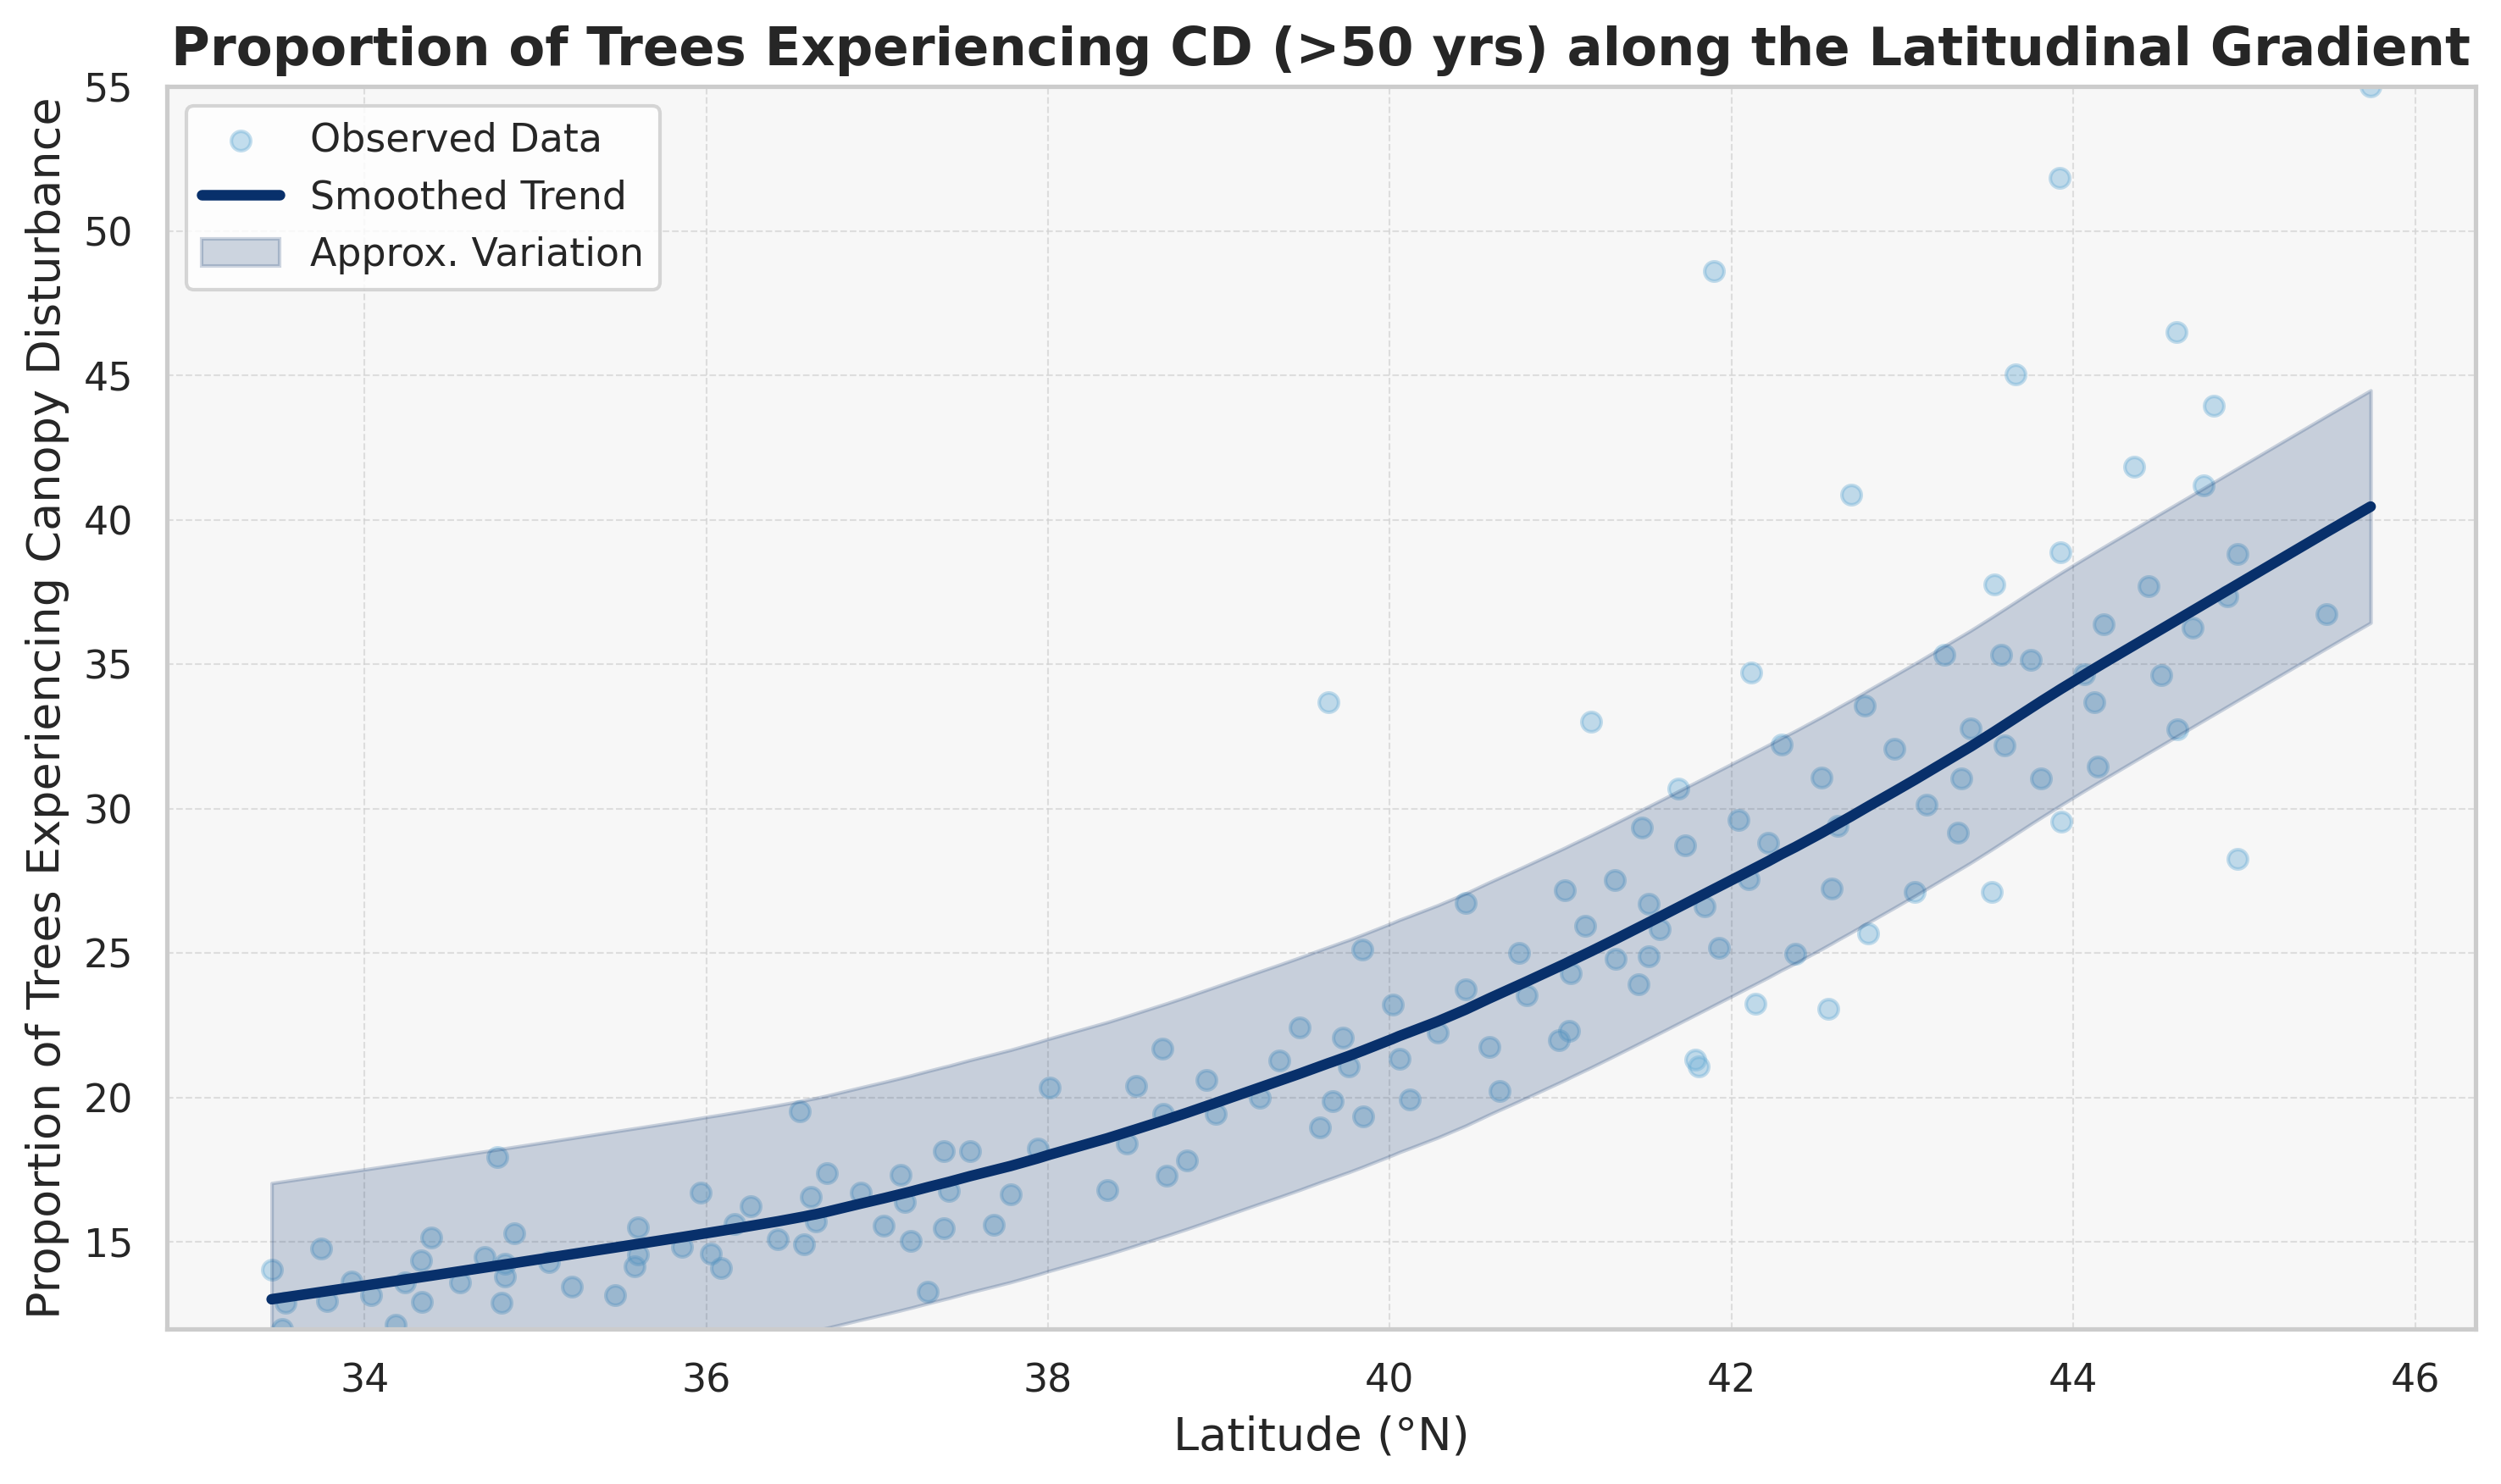

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np

# ---- Load Dataset ----
df = pd.read_csv("DefaultDataset3.csv", header=None)
df.columns = ["Latitude (degrees North)", "Proportion of Trees Experiencing CD"]
df = df.sort_values("Latitude (degrees North)")

# ---- Rescale Y-axis slightly larger than last time ----
y_new_min, y_new_max = 12, 55  # slightly expanded range
y_old_min, y_old_max = df["Proportion of Trees Experiencing CD"].min(), df["Proportion of Trees Experiencing CD"].max()
df["CD_scaled"] = (df["Proportion of Trees Experiencing CD"] - y_old_min) / (y_old_max - y_old_min)
df["CD_scaled"] = df["CD_scaled"] * (y_new_max - y_new_min) + y_new_min

# ---- Compute LOWESS smoothing on scaled data ----
frac = 0.35  # smoothing parameter
lowess_smoothed_scaled = lowess(
    endog=df["CD_scaled"],
    exog=df["Latitude (degrees North)"],
    frac=frac
)

# ---- Compute residuals for shaded variation ----
residuals_scaled = df["CD_scaled"].values - np.interp(
    df["Latitude (degrees North)"],
    lowess_smoothed_scaled[:,0],
    lowess_smoothed_scaled[:,1]
)
std_resid_scaled = np.std(residuals_scaled)

# ---- Custom plotting style ----
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6), dpi=300)
ax = plt.gca()
ax.set_facecolor("#f7f7f7")
plt.grid(color="lightgrey", linestyle="--", linewidth=0.5, alpha=0.7)

# ---- Plot raw data points ----
plt.scatter(
    df["Latitude (degrees North)"],
    df["CD_scaled"],
    color="#6baed6",
    alpha=0.4,
    s=30,
    label="Observed Data"
)

# ---- Plot LOWESS smoothed trend ----
plt.plot(
    lowess_smoothed_scaled[:,0],
    lowess_smoothed_scaled[:,1],
    color="#08306b",
    linewidth=3,
    label="Smoothed Trend"
)

# ---- Shaded area around trend (±1 SD) ----
plt.fill_between(
    lowess_smoothed_scaled[:,0],
    lowess_smoothed_scaled[:,1] - std_resid_scaled,
    lowess_smoothed_scaled[:,1] + std_resid_scaled,
    color="#08306b",
    alpha=0.2,
    label="Approx. Variation"
)

# ---- Labels & Title (as before) ----
plt.xlabel("Latitude (°N)", fontsize=13)
plt.ylabel("Proportion of Trees Experiencing Canopy Disturbance", fontsize=13)
plt.title(
    "Proportion of Trees Experiencing CD (>50 yrs) along the Latitudinal Gradient",
    fontsize=15,
    weight="bold"
)

plt.legend(fontsize=11)
plt.ylim(y_new_min, y_new_max)  # scaled y-axis
plt.tight_layout()

# ---- Save and Show ----
plt.savefig("Proportion of Trees Experiencing CD (>50 yrs) along the Latitudinal Gradient.png", dpi=300)
plt.show()
